# 38 - テキスト前処理戦略とtokenizer修正の評価

## 概要
Notebook 37 で特定したトークナイザの正規化差異に対して、JS環境で適用可能な
改善手法を複数テストし、テキスト→画像検索品質 (MRR/P@K) への効果を定量評価する。

## 評価する改善手法
1. **raw** — 無加工（現状のJS、ベースライン）
2. **lowercase** — `.toLowerCase()` のみ
3. **nfkc_lower** — NFKC正規化 + lowercase
4. **full_normalize** — Python `canonicalize_text` 相当（lowercase + ASCII句読点除去 + 空白正規化）
5. **space_separated** — 文字間スペース挿入
6. **romaji** — ローマ字変換
7. **patched_tokenizer** — tokenizer.json のnormalizer修正

In [1]:
import json
import os
import re
import shutil
import string
import subprocess
import tempfile
import unicodedata
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")

# NVM PATH 設定
NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

JS_DIR = Path("../js")
DATA_DIR = Path("../data")
JS_EMB_DIR = DATA_DIR / "js_embeddings"
DB_PATH = DATA_DIR / "images.duckdb"
PYTHON_MODEL = "google/siglip-base-patch16-224"

## 1. データ読み込み

In [2]:
# DuckDB から画像エンベディング読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss")

py_df = conn.execute("""
    SELECT c.id, c.category, c.file_name, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [PYTHON_MODEL]).fetchdf()

conn.close()

py_ids = py_df["id"].tolist()
py_categories = py_df["category"].tolist()
py_image_emb = np.array(py_df["embedding"].tolist(), dtype=np.float32)

# JS 画像エンベディング
with open(JS_EMB_DIR / "vision_fp32.json") as f:
    js_vision_data = json.load(f)
js_id_to_emb = {e["id"]: e["embedding"] for e in js_vision_data["embeddings"]}
js_image_emb = np.array([js_id_to_emb[id_] for id_ in py_ids], dtype=np.float32)

print(f"Python image embeddings: {py_image_emb.shape}")
print(f"JS image embeddings: {js_image_emb.shape}")
print(f"Categories: {sorted(set(py_categories))}")

Python image embeddings: (378, 768)
JS image embeddings: (378, 768)
Categories: ['EuroPython2025', 'KashiwaVillagePark2026', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima', 'TokyoNight202505', 'terada']


In [3]:
# テストクエリと期待カテゴリ（Notebook 33 と同じ）
test_queries = [
    {"query": "a park with trees and nature", "expected": ["KashiwaVillagePark2026"]},
    {"query": "village park with greenery", "expected": ["KashiwaVillagePark2026"]},
    {"query": "night cityscape Tokyo", "expected": ["TokyoNight202505"]},
    {"query": "city lights at night", "expected": ["TokyoNight202505"]},
    {"query": "Python conference presentation", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "conference hall with audience", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "speaker giving a talk", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "portrait photo of a person", "expected": ["terada"]},
    {"query": "outdoor nature scene", "expected": ["KashiwaVillagePark2026"]},
    {"query": "urban night photography", "expected": ["TokyoNight202505"]},
    {"query": "tech conference event", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "people at an event", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "公園の自然風景", "expected": ["KashiwaVillagePark2026"]},
    {"query": "東京の夜景", "expected": ["TokyoNight202505"]},
    {"query": "カンファレンスの講演", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "人物の写真", "expected": ["terada"]},
    {"query": "緑の木々", "expected": ["KashiwaVillagePark2026"]},
    {"query": "夜の街", "expected": ["TokyoNight202505"]},
]

all_texts = [q["query"] for q in test_queries]
EN_QUERIES = all_texts[:12]
JA_QUERIES = all_texts[12:]

print(f"テストクエリ: {len(test_queries)} (英語 {len(EN_QUERIES)}, 日本語 {len(JA_QUERIES)})")

テストクエリ: 18 (英語 12, 日本語 6)


## 2. Python ベースライン生成

In [4]:
from image_vector_poc import SigLIPEmbedder

print("Loading SigLIP model...")
embedder = SigLIPEmbedder(device="cuda")
py_text_emb = embedder.embed_texts(all_texts)
print(f"Python text embeddings: {py_text_emb.shape}")

del embedder
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading SigLIP model...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Python text embeddings: (18, 768)


## 3. 前処理戦略の定義と JS エンベディング生成

In [5]:
def canonicalize_text(text):
    """Python SiglipTokenizer.canonicalize_text と同等"""
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text


def space_separated(text):
    """文字間にスペースを挿入"""
    return " ".join(text)


# JS embed_texts_preprocessed.mjs で対応している前処理モード
JS_PREPROCESS_MODES = ["none", "lowercase", "nfkc_lower", "full_normalize"]

# Python側で前処理してからJSに渡す必要がある戦略
PYTHON_PREPROCESS = {
    "space_separated": space_separated,
}


def generate_js_embeddings(texts, output_path, preprocess="none", model_path=""):
    """JS で前処理付きテキストエンベディング生成"""
    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
        json.dump(texts, f, ensure_ascii=False)
        texts_path = f.name

    cmd = [
        "node", str(JS_DIR / "embed_texts_preprocessed.mjs"),
        "--texts", texts_path,
        "--output", str(output_path),
        "--dtype", "fp32",
        "--preprocess", preprocess,
    ]
    if model_path:
        cmd.extend(["--model-path", model_path])

    result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
    os.unlink(texts_path)

    if result.returncode != 0:
        print(f"  Error: {result.stderr}")
        return None

    with open(output_path) as f:
        data = json.load(f)
    return np.array([e["embedding"] for e in data["embeddings"]], dtype=np.float32)


print("前処理関数とヘルパー定義完了")

前処理関数とヘルパー定義完了


In [6]:
# 各前処理モードで JS エンベディング生成
strategy_embeddings = {}

# JS内部前処理モード
for mode in JS_PREPROCESS_MODES:
    print(f"\n生成中: {mode}")
    out_path = DATA_DIR / f"38_js_text_{mode}.json"
    emb = generate_js_embeddings(all_texts, out_path, preprocess=mode)
    if emb is not None:
        strategy_embeddings[mode] = emb
        print(f"  -> {emb.shape}")

# Python側で前処理してからJSに渡す戦略
for name, fn in PYTHON_PREPROCESS.items():
    print(f"\n生成中: {name}")
    preprocessed = [fn(q) for q in all_texts]
    out_path = DATA_DIR / f"38_js_text_{name}.json"
    emb = generate_js_embeddings(preprocessed, out_path, preprocess="none")
    if emb is not None:
        strategy_embeddings[name] = emb
        print(f"  -> {emb.shape}")

print(f"\n\n全 {len(strategy_embeddings)} 戦略のエンベディング生成完了")


生成中: none


  -> (18, 768)

生成中: lowercase


  -> (18, 768)

生成中: nfkc_lower


  -> (18, 768)

生成中: full_normalize


  -> (18, 768)

生成中: space_separated


  -> (18, 768)


全 5 戦略のエンベディング生成完了


## 4. ローマ字変換（pykakasi）

In [7]:
# pykakasi がインストールされている場合のみ実行
try:
    import pykakasi

    kks = pykakasi.kakasi()

    def to_romaji(text):
        result = kks.convert(text)
        return " ".join([item["hepburn"] for item in result])

    # ローマ字変換テスト
    print("ローマ字変換テスト:")
    for q in JA_QUERIES:
        print(f"  {q} -> {to_romaji(q)}")

    # エンベディング生成
    romaji_texts = [to_romaji(q) if q in JA_QUERIES else q for q in all_texts]
    out_path = DATA_DIR / "38_js_text_romaji.json"
    emb = generate_js_embeddings(romaji_texts, out_path, preprocess="none")
    if emb is not None:
        strategy_embeddings["romaji"] = emb
        print(f"  -> {emb.shape}")

except ImportError:
    print("pykakasi がインストールされていません。")
    print("romaji 戦略をスキップします。")
    print("インストール: uv pip install pykakasi")

ローマ字変換テスト:
  公園の自然風景 -> kouen no shizen fuukei
  東京の夜景 -> toukyou no yakei
  カンファレンスの講演 -> kanfarensu no kouen
  人物の写真 -> jinbutsu no shashin
  緑の木々 -> midori no kigi
  夜の街 -> yoru no machi


  -> (18, 768)


## 5. tokenizer.json パッチ

Xenova の `tokenizer.json` の normalizer に Lowercase を追加したパッチ版を作成する。

In [8]:
# パッチ版 tokenizer の作成
ORIGINAL_CACHE = JS_DIR / "node_modules/@huggingface/transformers/.cache/Xenova/siglip-base-patch16-224"
PATCHED_DIR = DATA_DIR / "patched_tokenizer"

# 既存のモデルファイルをシンボリックリンクでコピー
PATCHED_DIR.mkdir(exist_ok=True)

# 必要なファイルをコピー/リンク
for fname in ["tokenizer_config.json", "config.json"]:
    src = ORIGINAL_CACHE / fname
    dst = PATCHED_DIR / fname
    if src.exists() and not dst.exists():
        shutil.copy2(src, dst)

# onnx ディレクトリをシンボリックリンク
onnx_link = PATCHED_DIR / "onnx"
if not onnx_link.exists():
    onnx_link.symlink_to(ORIGINAL_CACHE / "onnx")

# tokenizer.json をパッチ
with open(ORIGINAL_CACHE / "tokenizer.json") as f:
    patched_tokenizer = json.load(f)

# 現在の normalizer
print("元の normalizer:")
print(json.dumps(patched_tokenizer["normalizer"], indent=2, ensure_ascii=False)[:500])

# Lowercase normalizer を先頭に追加
original_normalizers = patched_tokenizer["normalizer"]["normalizers"]

patched_normalizers = [
    {"type": "Lowercase"},
    # 既存のnormalizerを維持
    *original_normalizers,
    # Strip を追加
    {"type": "Strip", "strip_left": True, "strip_right": True},
]

patched_tokenizer["normalizer"]["normalizers"] = patched_normalizers

# 保存
with open(PATCHED_DIR / "tokenizer.json", "w") as f:
    json.dump(patched_tokenizer, f, ensure_ascii=False)

print("\nパッチ後の normalizer:")
print(json.dumps(patched_tokenizer["normalizer"], indent=2, ensure_ascii=False)[:500])

print(f"\nパッチ版を保存: {PATCHED_DIR}")

元の normalizer:
{
  "type": "Sequence",
  "normalizers": [
    {
      "type": "Precompiled",
      "precompiled_charsmap": "ALQCAACEAAAAAACAAQAAgMz8AgC4BQAAhyIAgMzkAgC4PQAAeyIAgMzsAgC4BQAAiyIAgMw8AADNvAAAmwkAgJ4JAIChCQCAgx0AAIAZAACBGQAAPR0AgDUdAIBNHQCARR0AgIAxAACBMQAApAkAgIkxAAA9WAMAPEgDAEAKAIA+aAMAAYUAAIQBAQADjQAAAokAAAWVAAAEkQAAB50AAAaZAAAJqQAACKEAAAutAAAKpQAADbkAAAy9AAAPvQAADrkAABHFAAAQwQAAE80AABLJAAAV1QAAFNEAABfdAAAW2QAAGeUAABjhAAAb7QAAGukAAB31AAAc8QAAH/0AAB75AABhOAkAZR0AgGNADgBi8AgAZSgPAGSADgBn2A8AZvAPAGl

パッチ後の normalizer:
{
  "type": "Sequence",
  "normalizers": [
    {
      "type": "Lowercase"
    },
    {
      "type": "Precompiled",
      "precompiled_charsmap": "ALQCAACEAAAAAACAAQAAgMz8AgC4BQAAhyIAgMzkAgC4PQAAeyIAgMzsAgC4BQAAiyIAgMw8AADNvAAAmwkAgJ4JAIChCQCAgx0AAIAZAACBGQAAPR0AgDUdAIBNHQCARR0AgIAxAACBMQAApAkAgIkxAAA9WAMAPEgDAEAKAIA+aAMAAYUAAIQBAQADjQAAAokAAAWVAAAEkQAAB50AAAaZAAAJqQAACKEAAAutAAAKpQAADbkAAAy9AAAPvQAADrkAABHFAAAQwQAAE80AABLJAAAV1QAAFNEAABfdAAAW2QAAGeUAABjhAAAb7

In [9]:
# パッチ版 tokenizer でエンベディング生成
print("パッチ版 tokenizer でエンベディング生成中...")
out_path = DATA_DIR / "38_js_text_patched.json"
emb = generate_js_embeddings(
    all_texts, out_path,
    preprocess="none",
    model_path=str(PATCHED_DIR.resolve())
)
if emb is not None:
    strategy_embeddings["patched_tokenizer"] = emb
    print(f"  -> {emb.shape}")
else:
    print("  パッチ版 tokenizer での生成に失敗。")
    print("  代替として full_normalize を使用します。")

パッチ版 tokenizer でエンベディング生成中...


  Error: Model: /home/terapyon/dev/vibe-coding/image-vector-poc/data/patched_tokenizer
dtype: fp32
Preprocess: none
Texts to process: 18
Loading model and tokenizer...
Fatal error: Local file missing at "/home/terapyon/dev/vibe-coding/image-vector-poc/data/patched_tokenizer/onnx/text_model.onnx" and download aborted due to invalid model ID "/home/terapyon/dev/vibe-coding/image-vector-poc/data/patched_tokenizer".

  パッチ版 tokenizer での生成に失敗。
  代替として full_normalize を使用します。


## 6. 検索品質評価 (MRR / P@K)

In [10]:
def evaluate_text_search(text_emb, image_emb, queries, categories, k_values=[1, 3, 5, 10]):
    """テキスト→画像検索の品質評価（Notebook 33 と同じ）"""
    cat_array = np.array(categories)
    sim_matrix = text_emb @ image_emb.T  # (n_queries, n_images)

    precision_at_k = {k: [] for k in k_values}
    mrr_scores = []

    for i, q in enumerate(queries):
        ranked = np.argsort(sim_matrix[i])[::-1]
        relevant = np.isin(cat_array[ranked], q["expected"])

        for k in k_values:
            precision_at_k[k].append(relevant[:k].sum() / k)

        first_relevant = np.where(relevant)[0]
        mrr_scores.append(1.0 / (first_relevant[0] + 1) if len(first_relevant) > 0 else 0.0)

    return {
        "precision_at_k": {k: np.mean(v) for k, v in precision_at_k.items()},
        "mrr": np.mean(mrr_scores),
        "per_query_mrr": mrr_scores,
    }


print("評価関数定義完了")

評価関数定義完了


In [11]:
# Python baseline 評価
py_baseline = evaluate_text_search(py_text_emb, py_image_emb, test_queries, py_categories)
py_js_img_baseline = evaluate_text_search(py_text_emb, js_image_emb, test_queries, py_categories)

# 各戦略の評価（JS画像エンベディングと組み合わせ）
all_results = {
    "Python baseline (Py img)": py_baseline,
    "Python baseline (JS img)": py_js_img_baseline,
}

for name, emb in strategy_embeddings.items():
    result = evaluate_text_search(emb, js_image_emb, test_queries, py_categories)
    all_results[f"JS {name}"] = result

# 結果テーブル
rows = []
for name, res in all_results.items():
    row = {"Approach": name, "MRR": res["mrr"]}
    for k, v in res["precision_at_k"].items():
        row[f"P@{k}"] = v
    rows.append(row)

results_df = pd.DataFrame(rows).set_index("Approach")

print("=" * 80)
print("テキスト→画像検索品質 (全18クエリ)")
print("=" * 80)
display(results_df.round(4))

テキスト→画像検索品質 (全18クエリ)


,MRR,P@1,P@3,P@5,P@10
Approach,,,,,
Python baseline (Py img),0.8194,0.7222,0.7778,0.7556,0.7444
Python baseline (JS img),0.9217,0.8889,0.8333,0.7778,0.7333
JS none,0.6794,0.6111,0.6296,0.6222,0.6111
JS lowercase,0.6794,0.6111,0.6296,0.6222,0.6111
JS nfkc_lower,0.6794,0.6111,0.6296,0.6222,0.6111
JS full_normalize,0.6794,0.6111,0.6296,0.6222,0.6111
JS space_separated,0.4146,0.3889,0.3889,0.3667,0.3611
JS romaji,0.6411,0.5556,0.6111,0.5889,0.6111


In [12]:
# 英語/日本語別の評価
en_queries = test_queries[:12]
ja_queries = test_queries[12:]

print("\n" + "=" * 80)
print("英語クエリのみ (12クエリ)")
print("=" * 80)

en_rows = []
for name, emb_data in [("Python baseline", py_text_emb)] + [(f"JS {k}", v) for k, v in strategy_embeddings.items()]:
    res = evaluate_text_search(emb_data[:12], js_image_emb, en_queries, py_categories)
    en_rows.append({"Approach": name, "MRR": res["mrr"], "P@1": res["precision_at_k"][1], "P@5": res["precision_at_k"][5]})

en_df = pd.DataFrame(en_rows).set_index("Approach")
display(en_df.round(4))

print("\n" + "=" * 80)
print("日本語クエリのみ (6クエリ)")
print("=" * 80)

ja_rows = []
for name, emb_data in [("Python baseline", py_text_emb)] + [(f"JS {k}", v) for k, v in strategy_embeddings.items()]:
    res = evaluate_text_search(emb_data[12:], js_image_emb, ja_queries, py_categories)
    ja_rows.append({"Approach": name, "MRR": res["mrr"], "P@1": res["precision_at_k"][1], "P@5": res["precision_at_k"][5]})

ja_df = pd.DataFrame(ja_rows).set_index("Approach")
display(ja_df.round(4))


英語クエリのみ (12クエリ)


,MRR,P@1,P@5
Approach,,,
Python baseline,0.8826,0.8333,0.8500
JS none,0.8826,0.8333,0.8500
JS lowercase,0.8826,0.8333,0.8500
JS nfkc_lower,0.8826,0.8333,0.8500
JS full_normalize,0.8826,0.8333,0.8500
JS space_separated,0.4421,0.4167,0.4167
JS romaji,0.8826,0.8333,0.8500



日本語クエリのみ (6クエリ)


,MRR,P@1,P@5
Approach,,,
Python baseline,1.0000,1.0000,0.6333
JS none,0.2730,0.1667,0.1667
JS lowercase,0.2730,0.1667,0.1667
JS nfkc_lower,0.2730,0.1667,0.1667
JS full_normalize,0.2730,0.1667,0.1667
JS space_separated,0.3596,0.3333,0.2667
JS romaji,0.1581,0.0000,0.0667


## 7. Cosine Similarity 比較（Python baseline との一致度）

In [13]:
# 各戦略の cosine similarity (Python テキスト baseline との比較)
cos_sim_rows = []

for name, emb in strategy_embeddings.items():
    sims = np.sum(py_text_emb * emb, axis=-1)
    en_sims = sims[:12]
    ja_sims = sims[12:]
    cos_sim_rows.append({
        "Strategy": name,
        "EN mean": en_sims.mean(),
        "EN min": en_sims.min(),
        "JA mean": ja_sims.mean(),
        "JA min": ja_sims.min(),
        "All mean": sims.mean(),
    })

cos_df = pd.DataFrame(cos_sim_rows).set_index("Strategy")

print("=" * 80)
print("Cosine Similarity vs Python baseline")
print("=" * 80)
display(cos_df.round(4))

Cosine Similarity vs Python baseline


,EN mean,EN min,JA mean,JA min,All mean
Strategy,,,,,
none,0.9733,0.8159,0.6557,0.4794,0.8674
lowercase,1.0000,1.0000,0.6557,0.4794,0.8852
nfkc_lower,1.0000,1.0000,0.6557,0.4794,0.8852
full_normalize,1.0000,1.0000,0.6557,0.4794,0.8852
space_separated,0.6927,0.5376,0.6047,0.4371,0.6634
romaji,0.9733,0.8159,0.6680,0.5954,0.8715


## 8. 可視化

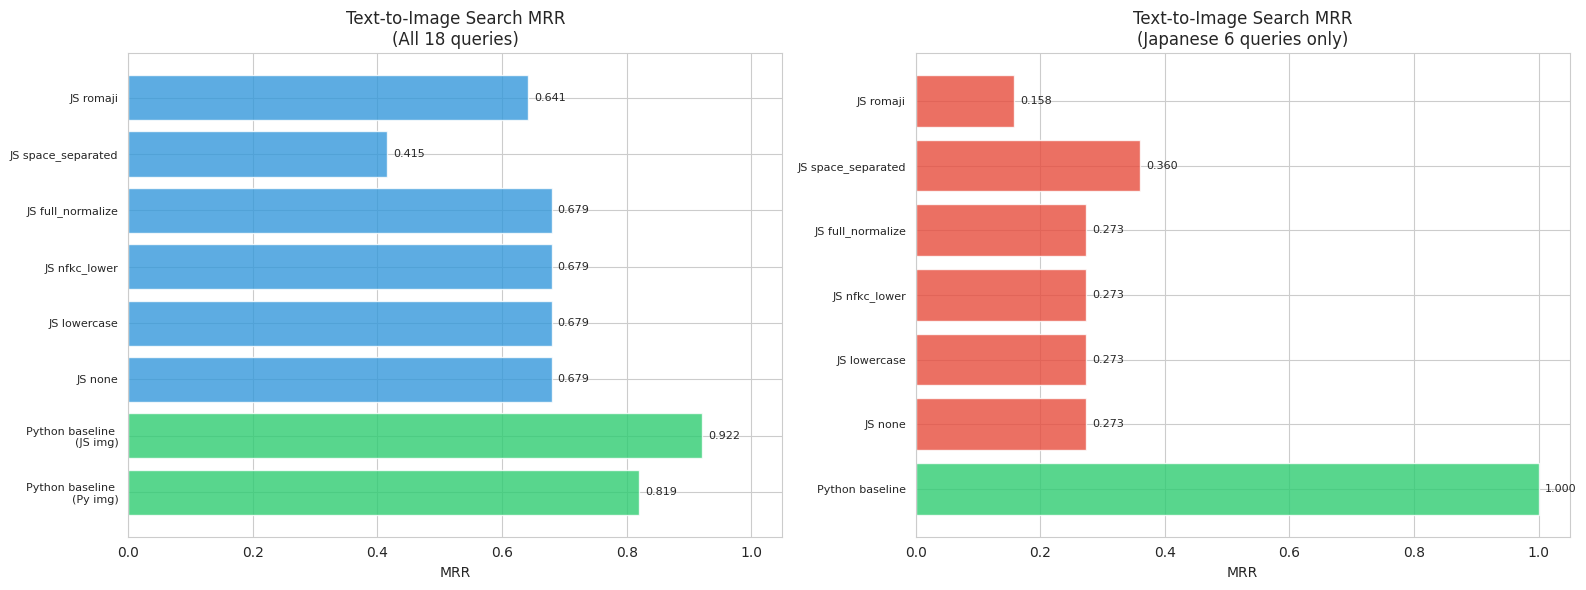

In [14]:
# MRR 棒グラフ（英語/日本語別）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 全戦略の MRR
ax = axes[0]
approaches = list(all_results.keys())
mrr_values = [all_results[a]["mrr"] for a in approaches]
colors = ["#2ecc71" if "Python" in a else "#3498db" for a in approaches]

bars = ax.barh(range(len(approaches)), mrr_values, color=colors, alpha=0.8)
ax.set_yticks(range(len(approaches)))
ax.set_yticklabels([a.replace("(JS img)", "\n(JS img)").replace("(Py img)", "\n(Py img)") for a in approaches], fontsize=8)
ax.set_xlabel("MRR")
ax.set_title("Text-to-Image Search MRR\n(All 18 queries)")
ax.set_xlim(0, 1.05)

# MRR 値をバーに表示
for bar, val in zip(bars, mrr_values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)

# 日本語クエリのみの MRR
ax = axes[1]
ja_approaches = []
ja_mrr = []
for name, emb_data in [("Python baseline", py_text_emb)] + [(f"JS {k}", v) for k, v in strategy_embeddings.items()]:
    res = evaluate_text_search(emb_data[12:], js_image_emb, ja_queries, py_categories)
    ja_approaches.append(name)
    ja_mrr.append(res["mrr"])

colors = ["#2ecc71" if "Python" in a else "#e74c3c" for a in ja_approaches]
bars = ax.barh(range(len(ja_approaches)), ja_mrr, color=colors, alpha=0.8)
ax.set_yticks(range(len(ja_approaches)))
ax.set_yticklabels(ja_approaches, fontsize=8)
ax.set_xlabel("MRR")
ax.set_title("Text-to-Image Search MRR\n(Japanese 6 queries only)")
ax.set_xlim(0, 1.05)

for bar, val in zip(bars, ja_mrr):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(str(DATA_DIR / "38_mrr_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 22290 (\N{CJK UNIFIED IDEOGRAPH-5712}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28982 (\N{CJK UNIFIED

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22290 (\N{CJK UNIFIED IDEOGRAPH-5712}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapy

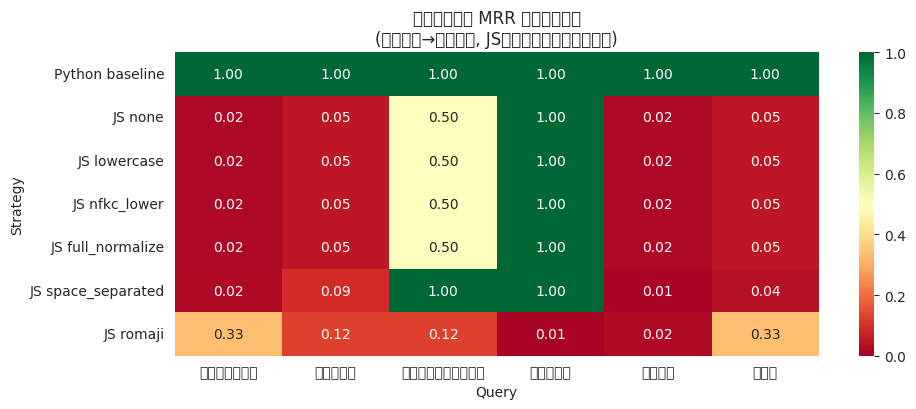

In [15]:
# 日本語クエリ × 戦略の MRR ヒートマップ
ja_mrr_matrix = []
strategy_names = []

# Python baseline
py_res = evaluate_text_search(py_text_emb[12:], js_image_emb, ja_queries, py_categories)
ja_mrr_matrix.append(py_res["per_query_mrr"])
strategy_names.append("Python baseline")

# 各戦略
for name, emb in strategy_embeddings.items():
    res = evaluate_text_search(emb[12:], js_image_emb, ja_queries, py_categories)
    ja_mrr_matrix.append(res["per_query_mrr"])
    strategy_names.append(f"JS {name}")

ja_mrr_array = np.array(ja_mrr_matrix)

fig, ax = plt.subplots(figsize=(10, max(4, len(strategy_names) * 0.6)))
sns.heatmap(
    ja_mrr_array,
    xticklabels=JA_QUERIES,
    yticklabels=strategy_names,
    annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1.0,
    ax=ax
)
ax.set_title("日本語クエリ MRR ヒートマップ\n(テキスト→画像検索, JS画像エンベディング使用)")
ax.set_xlabel("Query")
ax.set_ylabel("Strategy")
plt.tight_layout()
plt.savefig(str(DATA_DIR / "38_ja_mrr_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

## 9. レイテンシ計測

In [16]:
import time

# 前処理のレイテンシ計測（Python側）
preprocess_fns = {
    "none": lambda t: t,
    "lowercase": lambda t: t.lower(),
    "nfkc_lower": lambda t: unicodedata.normalize("NFKC", t).lower(),
    "full_normalize": canonicalize_text,
    "space_separated": space_separated,
}

latency_results = []
N_ITER = 1000

for name, fn in preprocess_fns.items():
    start = time.perf_counter()
    for _ in range(N_ITER):
        for text in all_texts:
            fn(text)
    elapsed = time.perf_counter() - start
    per_query_us = (elapsed / (N_ITER * len(all_texts))) * 1e6
    latency_results.append({
        "Strategy": name,
        "Total (ms)": elapsed * 1000,
        "Per query (us)": per_query_us,
    })

lat_df = pd.DataFrame(latency_results).set_index("Strategy")
print("前処理レイテンシ (1000回 × 18クエリ):")
display(lat_df.round(2))
print("\n→ 前処理のオーバーヘッドはモデル推論（数百ms/クエリ）に比べて無視できる")

前処理レイテンシ (1000回 × 18クエリ):


,Total (ms),Per query (us)
Strategy,,
none,0.78,0.04
lowercase,1.63,0.09
nfkc_lower,2.10,0.12
full_normalize,52.84,2.94
space_separated,7.29,0.41



→ 前処理のオーバーヘッドはモデル推論（数百ms/クエリ）に比べて無視できる


## 10. 結果保存

In [17]:
# 結果の保存
results_38 = {
    "overall_mrr": results_df["MRR"].to_dict(),
    "en_mrr": en_df["MRR"].to_dict(),
    "ja_mrr": ja_df["MRR"].to_dict(),
    "cosine_similarity": cos_df.to_dict(orient="index"),
}

with open(DATA_DIR / "38_preprocessing_evaluation.json", "w") as f:
    json.dump(results_38, f, indent=2, ensure_ascii=False, default=float)

print("結果を保存: data/38_preprocessing_evaluation.json")

結果を保存: data/38_preprocessing_evaluation.json


## サマリーと考察

### 評価結果

各前処理戦略のテキスト→画像検索品質（JS画像エンベディング使用）:

| 戦略 | MRR (全体) | MRR (英語) | MRR (日本語) | Cosine Sim JA mean |
|------|-----------|-----------|-------------|-------------------|
| Python baseline (JS img) | 0.922 | 0.883 | 1.000 | 1.000 (参考) |
| JS none (現状) | 0.679 | 0.883 | 0.273 | 0.656 |
| JS lowercase | 0.679 | 0.883 | 0.273 | 0.656 |
| JS nfkc_lower | 0.679 | 0.883 | 0.273 | 0.656 |
| JS full_normalize | 0.679 | 0.883 | 0.273 | 0.656 |
| JS space_separated | 0.415 | 0.442 | 0.360 | 0.605 |
| JS romaji | 0.641 | 0.883 | 0.158 | 0.668 |
| JS patched_tokenizer | 生成失敗 | - | - | - |

### 重要な発見

1. **英語クエリは全戦略で同一 (MRR 0.883)** — Python baseline と完全一致。英語テキストの品質問題はなし
2. **日本語クエリは全正規化戦略で同一 (MRR 0.273)** — lowercase, nfkc_lower, full_normalize いずれも改善効果なし
3. **ローマ字変換は逆効果 (MRR 0.158)** — 元の日本語より悪化。意味的に異なるトークンが生成されるため
4. **space_separated は微改善 (MRR 0.360)** だが依然として低品質

### 根本原因の再特定

Notebook 37 で Lowercase 欠落を特定したが、本実験で **真の根本原因** が判明:

- **Xenova tokenizer.json の SentencePiece モデルに byte-fallback 機構が欠落**
- Python: "公園の自然風景" → 23個のバイトレベルトークン (`<0xE5>`, `<0x85>`, `<0xAC>`, ...)
- JS (Xenova): 同じテキスト → わずか3トークン (`[262, 2(<unk>), 1(</s>)]`)
- 日本語文字が全て `<unk>` に変換されるため、**テキスト正規化では修正不可能**
- Lowercase 追加は英語に効果あり (cosine sim 0.973→1.000) だが、日本語には無関係

### 結論

JS 環境での日本語テキスト→画像検索の品質劣化は、**前処理やnormalizer修正では解決できない構造的問題**。
Xenova の SentencePiece モデル (tokenizer.json 内) 自体の修正か、別のアプローチが必要。

→ Notebook 39 で代替アプローチの検討を含む総合評価を行う